### Cluster 1 (1979 companies, 5 bankrupt)

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# Configuration
CLUSTER_ID = 1
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 0

# Data Loading
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

features_to_use = joblib.load(FEATURE_FILE)

X = df[features_to_use]
y = df["Bankrupt?"]

Loading data for Cluster 1...
Shape: (1979, 98)
Class Distribution:
Bankrupt?
0    1974
1       5
Name: count, dtype: int64


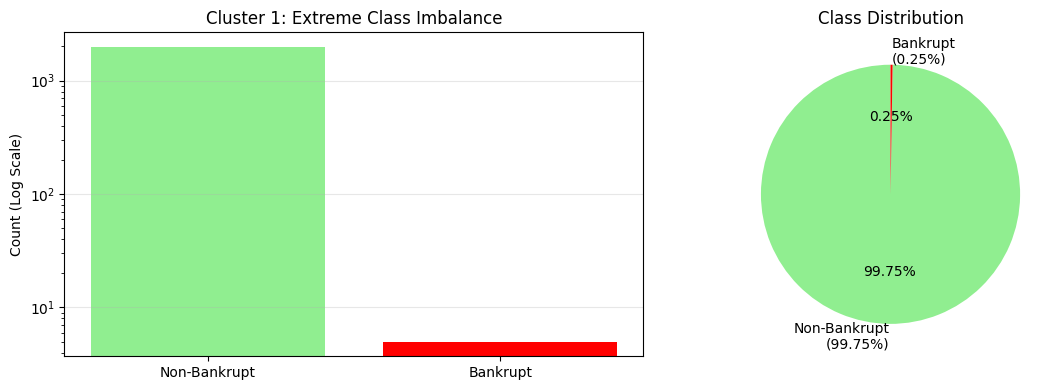

In [3]:
# Visual 1: Class Imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar Chart (Log Scale)
axes[0].bar(['Non-Bankrupt', 'Bankrupt'], [1974, 5], color=['lightgreen', 'red'])
axes[0].set_ylabel('Count (Log Scale)')
axes[0].set_title(f'Cluster {CLUSTER_ID}: Extreme Class Imbalance')
axes[0].set_yscale('log')  
axes[0].grid(axis='y', alpha=0.3)

# Pie Chart
axes[1].pie([1974, 5], labels=['Non-Bankrupt\n(99.75%)', 'Bankrupt\n(0.25%)'], 
            colors=['lightgreen', 'red'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_class_distribution.png", dpi=300)
plt.show()

Applying Global Scaling & PCA (N=8)...
Data Transformed. New Shape: (1979, 8)


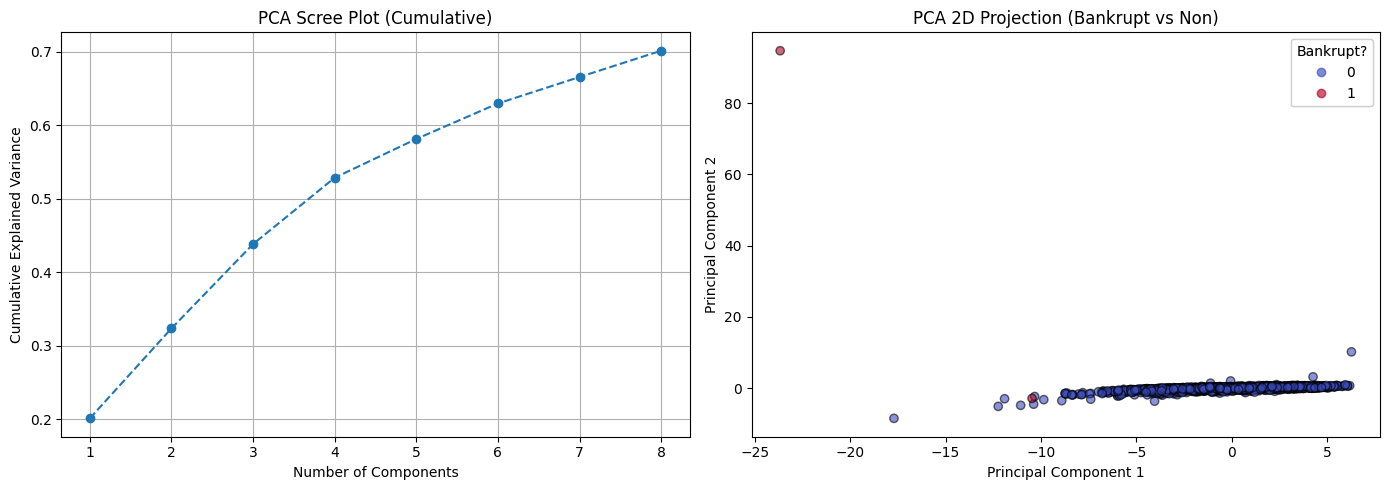

In [4]:
# GLOBAL PCA & MODEL DEFINITION
# -----------------------------
# Strategy: Use CatBoost, LightGBM, and RandomForest for robust stacking.

# 1. Global Preprocessing
print("Applying Global Scaling & PCA (N=8)...")
preprocessor = make_pipeline(
    StandardScaler(),
    PCA(n_components=8, random_state=RANDOM_STATE)
)
X_pca = preprocessor.fit_transform(X)
print(f"Data Transformed. New Shape: {X_pca.shape}")

# Visual 3: PCA Analysis
pca_model = preprocessor.named_steps['pca']
explained_variance = np.cumsum(pca_model.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].plot(range(1, 9), explained_variance, marker='o', linestyle='--')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Scree Plot (Cumulative)')
axes[0].grid(True)

# 2D Scatter Projection (PC1 vs PC2)
# Note: Imbalance is extreme, so bankrupcty points may be hard to distinguish without highlighting
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA 2D Projection (Bankrupt vs Non)')
legend1 = axes[1].legend(*scatter.legend_elements(), title="Bankrupt?")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

In [5]:
# 2. Define Base Models

rf_pipe = ImbPipeline([

    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE))
])

cat_pipe = ImbPipeline([

    ('cat', CatBoostClassifier(verbose=0, random_state=RANDOM_STATE, auto_class_weights='Balanced'))
])

lgbm_pipe = ImbPipeline([

    ('lgbm', LGBMClassifier(verbosity=-1, random_state=RANDOM_STATE, class_weight='balanced'))
])

estimators = [
    ('rf', rf_pipe),
    ('cat', cat_pipe),
    ('lgbm', lgbm_pipe)
]

# 3. Stacking Classifier
# StratifiedKFold(n_splits=2) ensures the 5 positive samples are split effectively.
cv_strategy = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

clf_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=cv_strategy,
    n_jobs=-1
)

clf_stack.fit(X_pca, y)
print("Training Complete.")

Training Complete.


RESULTS FOR TABLE 3 (Cluster 1)

Base Model Performance (on X_pca):
Base: rf
Confusion Matrix: [[1974, 0], [0, 5]]
Eq(1) Accuracy: 1.0000
Base: cat
Confusion Matrix: [[1974, 0], [0, 5]]
Eq(1) Accuracy: 1.0000
Base: lgbm
Confusion Matrix: [[1974, 0], [0, 5]]
Eq(1) Accuracy: 1.0000

Stacking Model Performance (Final):
STACKING MODEL
Confusion Matrix: [[1902, 72], [0, 5]]
Eq(1) Accuracy: 1.0000


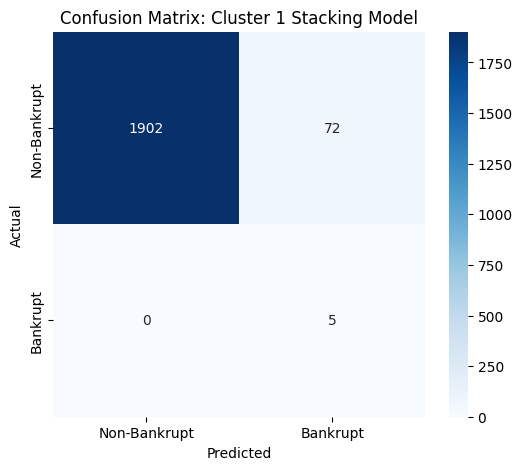


Model saved to cluster1_stacking.joblib
Stats for Table 3 -> TT: 5, TF: 0, N_features: 8


In [6]:
# Evaluation (Cluster 1)
def get_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    FF, FT, TF, TT = cm.ravel()
    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0
    print(f"{name}")
    print(f"Confusion Matrix: [[{FF}, {FT}], [{TF}, {TT}]]")
    print(f"Eq(1) Accuracy: {acc_eq1:.4f}")
    return FF, FT, TF, TT, acc_eq1

print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

# Base Models (Predict on X_pca)
print("\nBase Model Performance (on X_pca):")
for name, est in clf_stack.named_estimators_.items():
    y_pred_base = est.predict(X_pca)
    get_metrics(y, y_pred_base, f"Base: {name}")

# Stacking Model (Predict on X_pca)
print("\nStacking Model Performance (Final):")
y_pred_stack = clf_stack.predict(X_pca)
FF, FT, TF, TT, acc = get_metrics(y, y_pred_stack, "STACKING MODEL")

# Visual 4: Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_stack)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Bankrupt', 'Bankrupt'], 
            yticklabels=['Non-Bankrupt', 'Bankrupt'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: Cluster {CLUSTER_ID} Stacking Model')
plt.show()

# SAVE PACKAGE
# Critical: We save the FULL Pipeline (Preprocessor + Model) so transform happens automatically on load
full_model = make_pipeline(preprocessor, clf_stack)

model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": full_model,
    "stats": {"TT": TT, "TF": TF, "N_features": 8}
}

joblib.dump(model_package, OUTPUT_MODEL)
print(f"\nModel saved to {OUTPUT_MODEL}")
print(f"Stats for Table 3 -> TT: {TT}, TF: {TF}, N_features: 8")